# PDL Challenge 4: Understanding Word Embeddings with BERT

Single notebook covering every task in `PDL_challenge_4.pdf`, implemented in PyTorch with HuggingFace
`bert-base-uncased` on the IMDb movie review dataset.

| Section | Spec | Content |
|---|---|---|
| 1 | 3.4 | Load the pre-trained BERT model and tokenizer |
| 2 | 2 | Load and clean the IMDb dataset |
| 3 | 4 | Visualize pre-trained BERT embeddings with PCA and t-SNE |
| 4 | 5 | Fine-tune BERT for sentiment classification |
| 5 | 6 | Evaluate the fine-tuned model and inspect extreme predictions |
| 6 | 7 | K-means clustering on 64-dimensional fine-tuned embeddings |

**Colab:** select `Runtime > Change runtime type > T4 GPU` before running. Fine-tuning on the full
training set took about 5 minutes per epoch (roughly 11 minutes for 2 epochs) on a T4.

## 0. Setup

In [1]:
!pip install -q transformers datasets

In [2]:
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (BertModel, BertTokenizerFast, DataCollatorWithPadding,
                          get_linear_schedule_with_warmup)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, silhouette_score)
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU found. Fine-tuning on CPU will take many hours.")

device: cuda
GPU: Tesla T4


In [3]:
# Hyperparameters
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256          # tokens per review (reviews are truncated beyond this)
BATCH_SIZE = 32
EVAL_BATCH_SIZE = 128
EPOCHS = 2
LR = 2e-5
WARMUP_RATIO = 0.1
EMB_DIM = 64           # size of the bottleneck embedding used for clustering (spec section 7)
VAL_SIZE = 2500        # held out from the training split for per-epoch validation
N_VIS = 2000           # reviews used for the pre-trained embedding visualization
USE_AMP = device.type == "cuda"

## 1. Load the pre-trained BERT model (spec 3.4)

In [4]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
bert_pretrained = BertModel.from_pretrained(MODEL_NAME).to(device).eval()

print("Pre-trained BERT model and tokenizer have been loaded successfully.")
print("vocab size:", tokenizer.vocab_size)
print("hidden size:", bert_pretrained.config.hidden_size)

sample = "This is such an amazing movie!"
enc = tokenizer(sample)
print("tokens:", tokenizer.convert_ids_to_tokens(enc["input_ids"]))
print("ids:   ", enc["input_ids"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-trained BERT model and tokenizer have been loaded successfully.
vocab size: 30522
hidden size: 768
tokens: ['[CLS]', 'this', 'is', 'such', 'an', 'amazing', 'movie', '!', '[SEP]']
ids:    [101, 2023, 2003, 2107, 2019, 6429, 3185, 999, 102]


## 2. IMDb dataset (spec 2)

The HuggingFace `stanfordnlp/imdb` dataset has the official 25,000 / 25,000 train / test split, both balanced.
Reviews contain HTML line breaks (`<br />`), which are replaced by spaces. A small validation set is
held out from the training split so the test set is only touched once, in section 5.

In [5]:
raw = load_dataset("stanfordnlp/imdb")

def clean(batch):
    return {"text": [re.sub(r"<br\s*/?>", " ", t) for t in batch["text"]]}

raw = raw.map(clean, batched=True)
split = raw["train"].train_test_split(test_size=VAL_SIZE, seed=SEED, stratify_by_column="label")
train_raw, val_raw, test_raw = split["train"], split["test"], raw["test"]

LABEL_NAMES = ["negative", "positive"]
print(f"train: {len(train_raw)}  val: {len(val_raw)}  test: {len(test_raw)}")
print("train label counts:", np.bincount(train_raw["label"]))
print("test  label counts:", np.bincount(test_raw["label"]))

n_len = min(2000, len(train_raw))
lengths = [len(tokenizer.tokenize(t)) for t in train_raw.select(range(n_len))["text"]]
print(f"token length on {n_len} reviews: median {np.median(lengths):.0f}, "
      f"{np.mean(np.array(lengths) <= MAX_LEN) * 100:.1f}% fit within MAX_LEN={MAX_LEN}")

pd.DataFrame(train_raw.select(range(5))).assign(text=lambda d: d.text.str[:150] + "...")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

train: 22500  val: 2500  test: 25000
train label counts: [11250 11250]


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1052 > 512). Running this sequence through the model will result in indexing errors


test  label counts: [12500 12500]
token length on 2000 reviews: median 218, 58.9% fit within MAX_LEN=256


,text,label
0,Every generation fully believes it is living i...,0
1,This movie has one of the cheesiest plots I ha...,1
2,Because 'cruel' would be the only word in exis...,0
3,Even though many people here praises this movi...,0
4,"Meatball Machine is an amazing splatter film, ...",1


In [6]:
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

cols = ["input_ids", "token_type_ids", "attention_mask", "label"]
train_ds = train_raw.map(tokenize, batched=True).with_format("torch", columns=cols)
val_ds = val_raw.map(tokenize, batched=True).with_format("torch", columns=cols)
test_ds = test_raw.map(tokenize, batched=True).with_format("torch", columns=cols)

# Pads each batch only to its own longest sequence
collator = DataCollatorWithPadding(tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, collate_fn=collator, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, collate_fn=collator, num_workers=2)

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

## 3. Visualizing pre-trained BERT embeddings (spec 4)

For a balanced subset of reviews, the last hidden layer of the *pre-trained* (not yet fine-tuned)
BERT is reduced to one 768-dimensional vector per review in two ways:

- **[CLS]**: the hidden state of the first token.
- **Mean pooling**: the average of all non-padding token states.

Both are projected to 2D with PCA (linear) and t-SNE (non-linear) and coloured by sentiment label.
Since pre-trained BERT was never trained on sentiment, little separation is expected here; compare
against the fine-tuned embeddings in section 6.

In [7]:
@torch.no_grad()
def pretrained_embeddings(texts, batch_size=64):
    cls_list, mean_list = [], []
    for i in tqdm(range(0, len(texts), batch_size), desc="embedding"):
        enc = tokenizer(texts[i:i + batch_size], truncation=True, max_length=MAX_LEN,
                        padding=True, return_tensors="pt").to(device)
        with torch.autocast(device.type, enabled=USE_AMP):
            hidden = bert_pretrained(**enc).last_hidden_state.float()
        mask = enc["attention_mask"].unsqueeze(-1).float()
        cls_list.append(hidden[:, 0].cpu())
        mean_list.append(((hidden * mask).sum(1) / mask.sum(1)).cpu())
    return torch.cat(cls_list).numpy(), torch.cat(mean_list).numpy()

vis_raw = train_raw.shuffle(seed=SEED).select(range(N_VIS))
vis_labels = np.array(vis_raw["label"])
vis_cls, vis_mean = pretrained_embeddings(vis_raw["text"])
print("embedding shape:", vis_cls.shape)

embedding:   0%|          | 0/32 [00:00<?, ?it/s]

embedding shape: (2000, 768)


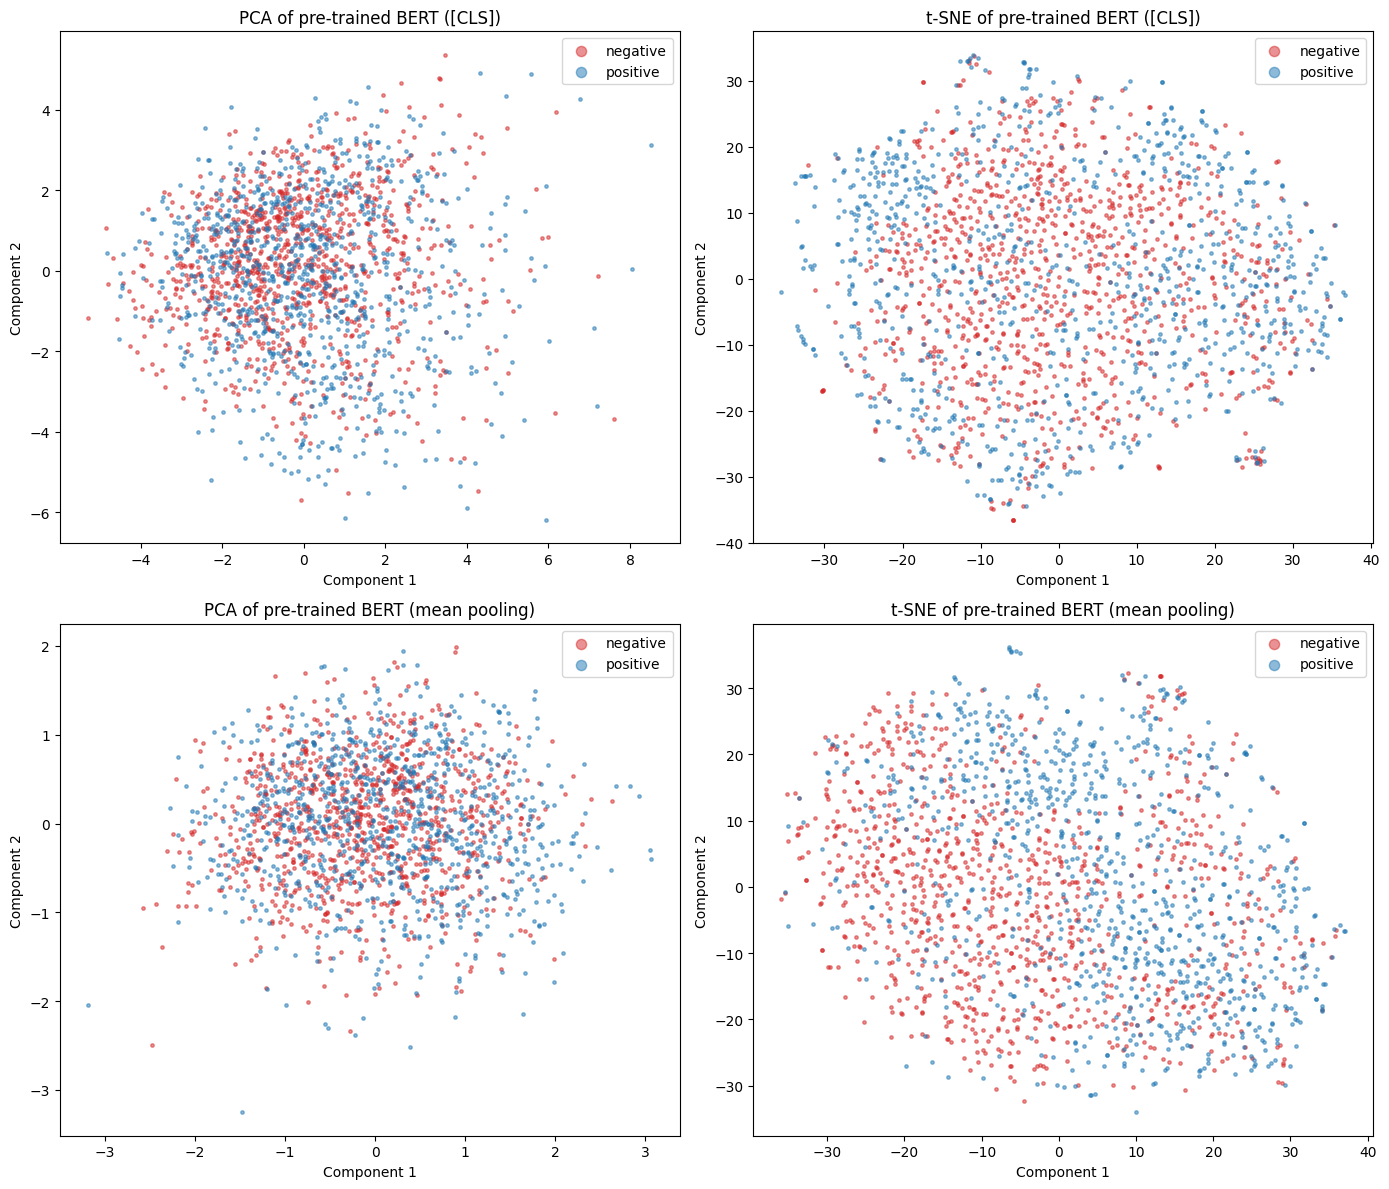

In [8]:
def scatter_by_label(ax, points, labels, title):
    for lab, color in zip([0, 1], ["tab:red", "tab:blue"]):
        idx = labels == lab
        ax.scatter(points[idx, 0], points[idx, 1], s=6, alpha=0.5, c=color, label=LABEL_NAMES[lab])
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(markerscale=3)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for row, (name, emb) in enumerate([("[CLS]", vis_cls), ("mean pooling", vis_mean)]):
    pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(emb)
    tsne_2d = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30).fit_transform(emb)
    scatter_by_label(axes[row, 0], pca_2d, vis_labels, f"PCA of pre-trained BERT ({name})")
    scatter_by_label(axes[row, 1], tsne_2d, vis_labels, f"t-SNE of pre-trained BERT ({name})")
plt.tight_layout()
plt.show()

**Observation.** With the pre-trained model the two classes overlap heavily. In both PCA plots
positive and negative reviews are mixed into one cloud, so sentiment is not a dominant linear
direction of the raw embedding. t-SNE shows only a weak regional tendency, a little clearer for mean
pooling than for [CLS], with negative reviews to the left and positive to the right. Pre-trained BERT
encodes *what a review is about* more than *how the reviewer felt*; it needs fine-tuning before the
classes separate (compare with section 6.2).

### Token-level embeddings of a single review

The same idea at word level: every token of one review, projected with PCA. Words with related
meaning or role tend to land close together.

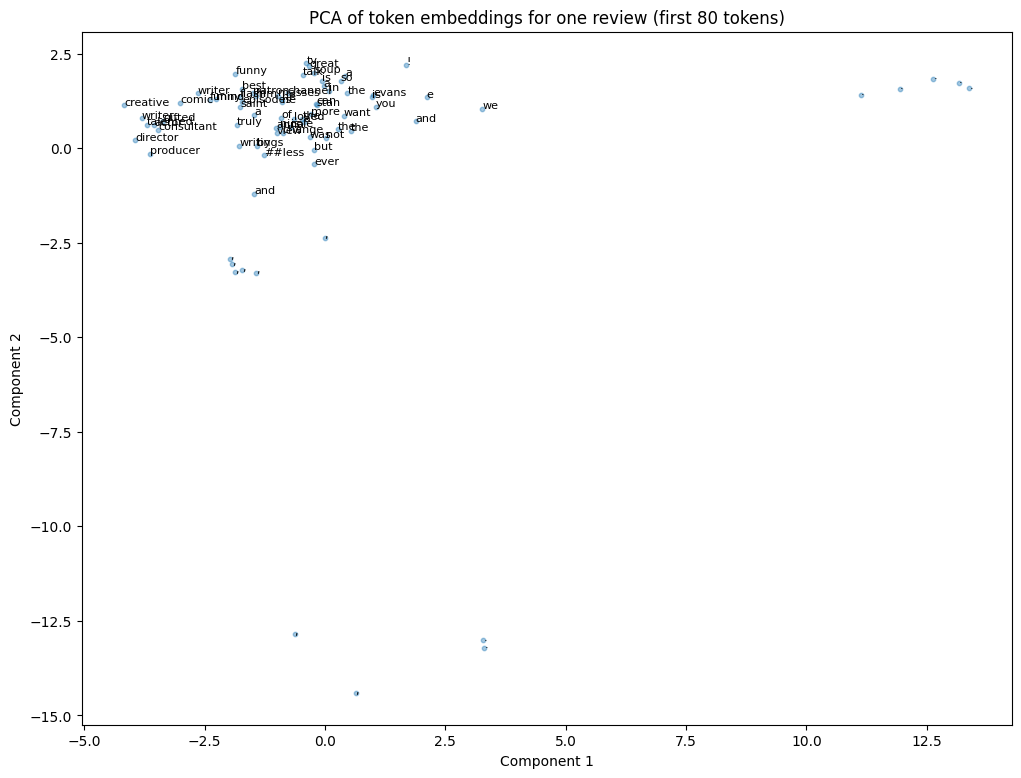

In [9]:
@torch.no_grad()
def token_embeddings(text):
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
    hidden = bert_pretrained(**enc).last_hidden_state[0, 1:-1].cpu().numpy()  # drop [CLS] and [SEP]
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0, 1:-1])
    return tokens, hidden

tokens, hidden = token_embeddings(vis_raw[0]["text"])
tokens, hidden = tokens[:80], hidden[:80]
pts = PCA(n_components=2, random_state=SEED).fit_transform(hidden)

plt.figure(figsize=(12, 9))
plt.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4)
for (x, y), tok in zip(pts, tokens):
    plt.annotate(tok, (x, y), fontsize=8)
plt.title("PCA of token embeddings for one review (first 80 tokens)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [10]:
# Free the pre-trained model before fine-tuning
del bert_pretrained
torch.cuda.empty_cache()

## 4. Fine-tuning BERT for sentiment analysis (spec 5)

The spec's example uses TensorFlow's `TFBertForSequenceClassification`. This notebook uses the
PyTorch equivalent, with one change needed for section 6: a 64-dimensional bottleneck layer is placed
between BERT's pooled `[CLS]` output and the classifier.

```
BERT (768) -> dropout -> Linear(768, 64) -> tanh  => 64-d review embedding
                                               -> dropout -> Linear(64, 2) => logits
```

The whole network (BERT included) is trained end to end with AdamW, a linear warmup/decay schedule,
and mixed precision to speed up training on the GPU.

In [11]:
class BertSentiment(nn.Module):
    def __init__(self, model_name, emb_dim=EMB_DIM, num_labels=2, dropout=0.1):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.bottleneck = nn.Linear(self.bert.config.hidden_size, emb_dim)
        self.classifier = nn.Linear(emb_dim, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, return_embedding=False):
        pooled = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                           token_type_ids=token_type_ids).pooler_output
        emb = torch.tanh(self.bottleneck(self.dropout(pooled)))
        logits = self.classifier(self.dropout(emb))
        return (logits, emb) if return_embedding else logits

model = BertSentiment(MODEL_NAME).to(device)
print(f"trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable parameters: 109,531,586


In [12]:
def to_device(batch):
    return {k: v.to(device) for k, v in batch.items()}

@torch.no_grad()
def run_inference(model, loader, desc="eval"):
    # Returns labels, positive-class probabilities, predictions and 64-d embeddings
    model.eval()
    labels, probs, embs = [], [], []
    for batch in tqdm(loader, desc=desc, leave=False):
        batch = to_device(batch)
        y = batch.pop("labels")
        with torch.autocast(device.type, enabled=USE_AMP):
            logits, emb = model(**batch, return_embedding=True)
        labels.append(y.cpu())
        probs.append(torch.softmax(logits.float(), dim=-1)[:, 1].cpu())
        embs.append(emb.float().cpu())
    labels = torch.cat(labels).numpy()
    probs = torch.cat(probs).numpy()
    return labels, probs, (probs >= 0.5).astype(int), torch.cat(embs).numpy()

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(WARMUP_RATIO * total_steps), total_steps)
scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)
loss_fn = nn.CrossEntropyLoss()

history = []
step_losses = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    start, running, correct, seen = time.time(), 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        batch = to_device(batch)
        y = batch.pop("labels")
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device.type, enabled=USE_AMP):
            logits = model(**batch)
            loss = loss_fn(logits.float(), y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running += loss.item() * y.size(0)
        correct += (logits.argmax(-1) == y).sum().item()
        seen += y.size(0)
        step_losses.append(loss.item())
        pbar.set_postfix(loss=f"{running / seen:.4f}", acc=f"{correct / seen:.4f}")

    val_y, _, val_pred, _ = run_inference(model, val_loader, desc="validation")
    record = {"epoch": epoch, "train_loss": running / seen, "train_acc": correct / seen,
              "val_acc": accuracy_score(val_y, val_pred), "minutes": (time.time() - start) / 60}
    history.append(record)
    print(record)

torch.save(model.state_dict(), "bert_imdb_sentiment.pt")
pd.DataFrame(history)

epoch 1/2:   0%|          | 0/704 [00:00<?, ?it/s]

validation:   0%|          | 0/20 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.3258660503334469, 'train_acc': 0.8569333333333333, 'val_acc': 0.9168, 'minutes': 5.168662587801616}


epoch 2/2:   0%|          | 0/704 [00:00<?, ?it/s]

validation:   0%|          | 0/20 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.1604586683683925, 'train_acc': 0.9453333333333334, 'val_acc': 0.9188, 'minutes': 5.2621064702669775}


,epoch,train_loss,train_acc,val_acc,minutes
0,1,0.325866,0.856933,0.9168,5.168663
1,2,0.160459,0.945333,0.9188,5.262106


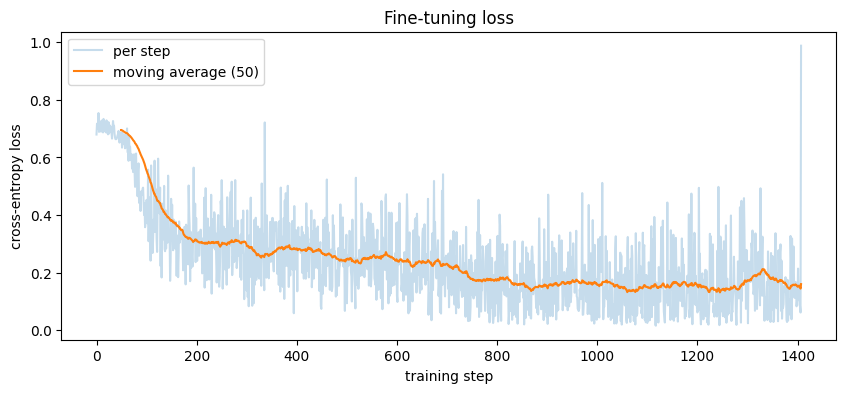

In [14]:
window = min(50, len(step_losses))
smoothed = np.convolve(step_losses, np.ones(window) / window, mode="valid")
plt.figure(figsize=(10, 4))
plt.plot(step_losses, alpha=0.25, label="per step")
plt.plot(np.arange(window - 1, len(step_losses)), smoothed, label=f"moving average ({window})")
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.title("Fine-tuning loss")
plt.legend()
plt.show()

**Observation.** Validation accuracy reaches 91.7% after one epoch and only 91.9% after the second,
while training accuracy rises from 85.7% to 94.5%. Most of the gain comes in the first epoch, and the
growing train/validation gap means a third epoch would probably start to overfit. Each epoch took
about 5 minutes on a T4. Note that only about 59% of reviews fit within `MAX_LEN = 256` tokens, so
the rest are truncated; longer inputs might gain a little accuracy at a higher compute cost.

### Example predictions (spec 5.1)

In [15]:
@torch.no_grad()
def predict(sentences):
    model.eval()
    enc = tokenizer(sentences, truncation=True, max_length=MAX_LEN, padding=True,
                    return_tensors="pt").to(device)
    probs = torch.softmax(model(**enc).float(), dim=-1)[:, 1].cpu().numpy()
    for s, p in zip(sentences, probs):
        print(f"{LABEL_NAMES[int(p >= 0.5)]:>8}  (P(positive) = {p:.3f})  {s}")

predict([
    "worst movie of my life, will never watch movies from this series",
    "Wow, blew my mind, what a movie by Marvel, animation and story is amazing",
    "The acting was fine but the plot dragged on and I nearly fell asleep.",
    "Not the best film ever made, but I still had a great time watching it.",
])

negative  (P(positive) = 0.013)  worst movie of my life, will never watch movies from this series
positive  (P(positive) = 0.986)  Wow, blew my mind, what a movie by Marvel, animation and story is amazing
negative  (P(positive) = 0.017)  The acting was fine but the plot dragged on and I nearly fell asleep.
positive  (P(positive) = 0.987)  Not the best film ever made, but I still had a great time watching it.


## 5. Investigating the fine-tuned model (spec 6)

### 5.1 Performance on the 25,000-review test set

One pass over the test set collects the labels, the predicted probabilities, and the 64-d
embeddings used again in section 6.

test:   0%|          | 0/196 [00:00<?, ?it/s]

accuracy : 0.9215
precision: 0.9104
recall   : 0.9350
F1-score : 0.9226

              precision    recall  f1-score   support

    negative     0.9332    0.9080    0.9204     12500
    positive     0.9104    0.9350    0.9226     12500

    accuracy                         0.9215     25000
   macro avg     0.9218    0.9215    0.9215     25000
weighted avg     0.9218    0.9215    0.9215     25000



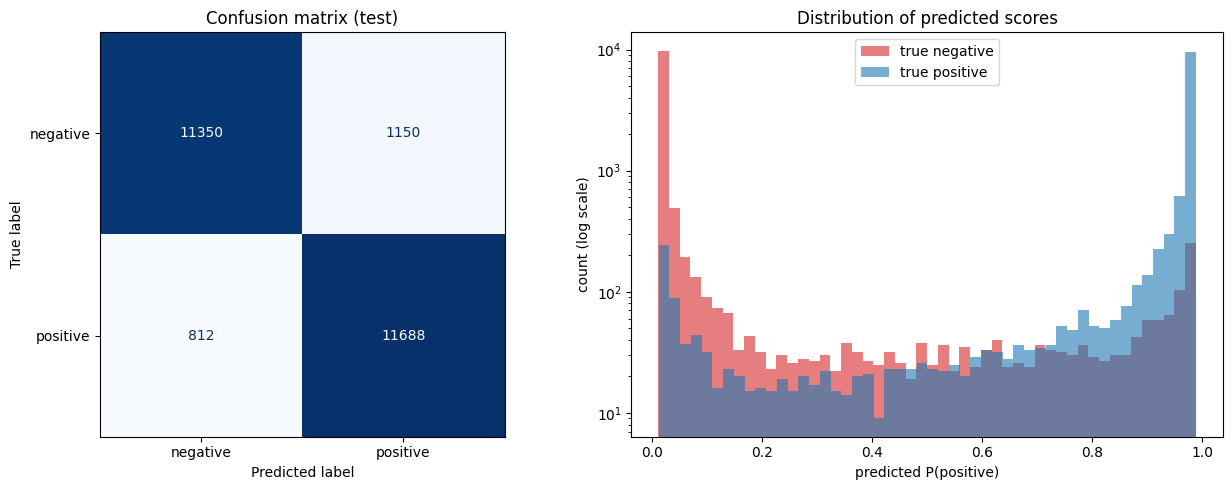

In [16]:
test_y, test_prob, test_pred, test_emb = run_inference(model, test_loader, desc="test")

acc = accuracy_score(test_y, test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(test_y, test_pred, average="binary")
print(f"accuracy : {acc:.4f}")
print(f"precision: {prec:.4f}")
print(f"recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print(classification_report(test_y, test_pred, target_names=LABEL_NAMES, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(test_y, test_pred), display_labels=LABEL_NAMES).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Confusion matrix (test)")
axes[1].hist(test_prob[test_y == 0], bins=50, alpha=0.6, color="tab:red", label="true negative")
axes[1].hist(test_prob[test_y == 1], bins=50, alpha=0.6, color="tab:blue", label="true positive")
axes[1].set_yscale("log")
axes[1].set_xlabel("predicted P(positive)")
axes[1].set_ylabel("count (log scale)")
axes[1].set_title("Distribution of predicted scores")
axes[1].legend()
plt.tight_layout()
plt.show()

### 5.2 Most positive and most negative reviews (spec 6.2)

Reviews are ranked by predicted P(positive). The most confident *mistakes* are also listed, since
they are usually the most informative about where the model and human judgement disagree.

In [17]:
test_df = pd.DataFrame({"text": test_raw["text"], "label": test_y, "p_pos": test_prob, "pred": test_pred})

def show(df, title, n_chars=400):
    print("=" * 100)
    print(title)
    print("=" * 100)
    for _, r in df.iterrows():
        print(f"[P(positive) = {r.p_pos:.4f} | true label: {LABEL_NAMES[r.label]}]")
        print(r.text[:n_chars] + ("..." if len(r.text) > n_chars else ""))
        print("-" * 100)

N_SHOW = 5
show(test_df.nlargest(N_SHOW, "p_pos"), "MOST POSITIVE REVIEWS")
show(test_df.nsmallest(N_SHOW, "p_pos"), "MOST NEGATIVE REVIEWS")

wrong = test_df[test_df.pred != test_df.label]
show(wrong.nlargest(3, "p_pos"), "CONFIDENT MISTAKES: predicted positive, actually negative")
show(wrong.nsmallest(3, "p_pos"), "CONFIDENT MISTAKES: predicted negative, actually positive")

MOST POSITIVE REVIEWS
[P(positive) = 0.9888 | true label: positive]
Roy Thinnes and Joan Hackett are superb in this 1970 melodrama. The lush settings, the haunting music, and plot twists make it a truly interesting film. I had seen it when it first came out on TV. Once more it aired when I had a VCR, but I did not have a chance to tape it. Would love it on VHS if someone has a copy. Apart from the suspense (which is worked in beautifully) I feel the story is uniqu...
----------------------------------------------------------------------------------------------------
[P(positive) = 0.9888 | true label: positive]
I first saw this film when I was in the 8th grade and I remember that it had a profound affect on me then. I saw in again about a year ago (I am now 29) and it still moved me in similar ways. This is a great movie that personifies the struggle of "principle vs. pragmistism". Voight's character is the idealist teacher that won't give in to any psuedo-racist leanings of the Superi

**Analysis.**

- **The extremes are unambiguous.** The most positive reviews are full of explicit praise ("superb",
  "I recommend it", "the acting is superb", "wonderful touch") and the most negative ones of explicit
  condemnation ("a disappointing mess", "don't waste a second", "very poor acting, poor script").
  A human would rank these the same way, so at the extremes the model agrees with human judgement.
- **Scores saturate.** All five reviews at each end get the same score (0.9888 and 0.0113). The
  `tanh` bottleneck saturates, so the model has a ceiling on confidence and the order *within* the
  top 5 is effectively a tie. The histogram in 5.1 shows the same thing: most reviews pile up in the
  first and last bins.
- **The confident mistakes fall into three groups:**
  1. *Sarcasm.* The "greatest horror movie" review praises Charles Band's catalogue ironically, and
     the Mob film review ends with "I have the brain capacity of an earth worm". The literal words are
     positive, but the intent is negative. BERT reads the surface sentiment and misses the irony.
  2. *"So bad it's good" and genre fans.* The exploitation-film review ("crassly pandering hunk of
     blithely rancid ... junk", "commendable lack of taste") is labelled positive: the reviewer enjoys
     the film *because* it is trashy. The vocabulary is overwhelmingly negative.
  3. *Text and rating that disagree.* "Absolute and utter filth" and "suffers from terrible acting"
     are labelled positive, and "I've developed an enjoyment of the simple plot" is labelled negative.
     No reasonable reader would guess these labels from the text, so they are best treated as label
     noise, or as ratings driven by something the review does not say.
- **Error balance.** There are 1,150 false positives against 812 false negatives (recall 0.935 vs.
  precision 0.910 for the positive class). The model leans slightly positive, which is consistent with
  failure modes 1 and 2: negative reviews written in positive words fool it more often than the
  reverse.

## 6. Exploring reviewer sentiments with K-means clustering (spec 7)

### 6.1 Choosing the number of clusters

The 64-d bottleneck embeddings from the fine-tuned model (collected in 5.1) are standardized and
clustered with K-means for k = 2 to 10. The elbow of the inertia curve and the silhouette score
(computed on a 5,000-review sample to keep it fast) guide the choice of k.

embedding matrix: (25000, 64)


k-means:   0%|          | 0/9 [00:00<?, ?it/s]

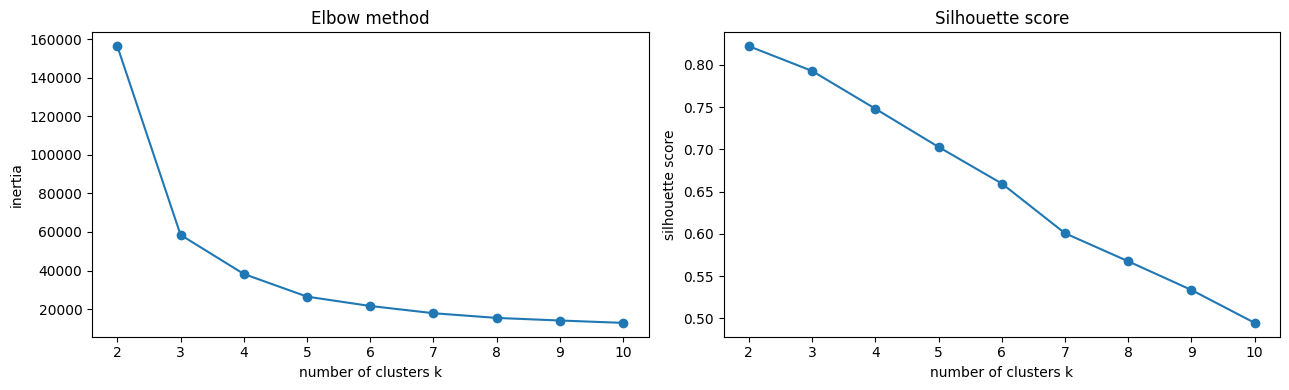

k= 2  silhouette=0.8223
k= 3  silhouette=0.7929
k= 4  silhouette=0.7482
k= 5  silhouette=0.7029
k= 6  silhouette=0.6596
k= 7  silhouette=0.6007
k= 8  silhouette=0.5675
k= 9  silhouette=0.5335
k=10  silhouette=0.4946


In [18]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(test_emb)
print("embedding matrix:", X.shape)

k_values = list(range(2, 11))
inertias, silhouettes = [], []
for k in tqdm(k_values, desc="k-means"):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_, sample_size=5000, random_state=SEED))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_xlabel("number of clusters k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow method")
axes[1].plot(k_values, silhouettes, marker="o")
axes[1].set_xlabel("number of clusters k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

for k, s in zip(k_values, silhouettes):
    print(f"k={k:2d}  silhouette={s:.4f}")

Because the embeddings were trained only to separate positive from negative, k = 2 usually scores
best on silhouette: the two big clusters are simply the two sentiment classes. To look for structure
*beyond* positive/negative, as the spec asks, a larger k is used for interpretation. `K_CHOSEN`
defaults to the best silhouette among k >= 3; change it after looking at the curves above.

In [19]:
K_CHOSEN = k_values[int(np.argmax(silhouettes[1:])) + 1]   # best k among k >= 3
print("K_CHOSEN =", K_CHOSEN)

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=SEED, n_init=10).fit(X)
test_df["cluster"] = kmeans.labels_

K_CHOSEN = 3


### 6.2 Visualizing the clusters

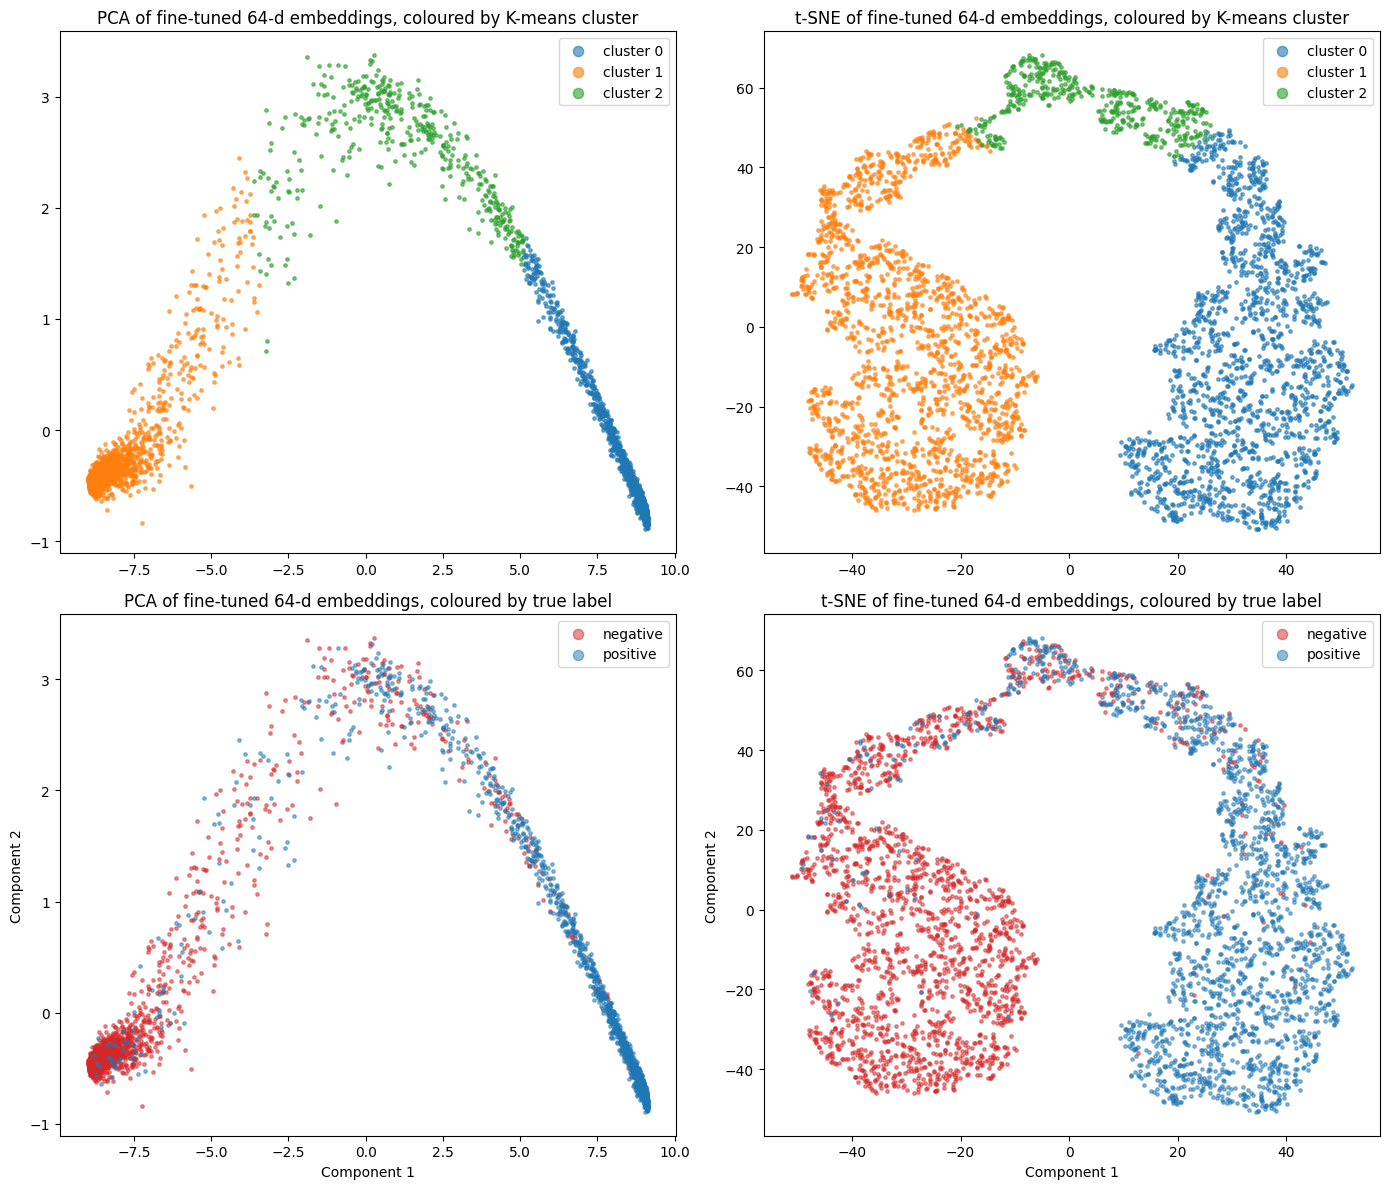

In [20]:
rng = np.random.default_rng(SEED)
vis_idx = rng.choice(len(X), size=min(4000, len(X)), replace=False)
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X[vis_idx])
tsne_2d = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30).fit_transform(X[vis_idx])
clusters = kmeans.labels_[vis_idx]
labels = test_y[vis_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for col, (name, pts) in enumerate([("PCA", pca_2d), ("t-SNE", tsne_2d)]):
    ax = axes[0, col]
    for c in range(K_CHOSEN):
        idx = clusters == c
        ax.scatter(pts[idx, 0], pts[idx, 1], s=6, alpha=0.6, label=f"cluster {c}")
    ax.set_title(f"{name} of fine-tuned 64-d embeddings, coloured by K-means cluster")
    ax.legend(markerscale=3)
    scatter_by_label(axes[1, col], pts, labels, f"{name} of fine-tuned 64-d embeddings, coloured by true label")
plt.tight_layout()
plt.show()

### 6.3 Interpreting the clusters (spec 7.2)

For each cluster:

- size, share of truly positive reviews, and mean predicted P(positive);
- the most distinctive words (mean TF-IDF inside the cluster minus the mean over all reviews);
- how often each cluster mentions a set of theme words (visual, story, acting, music, emotion, ...),
  relative to the whole test set;
- a few example reviews closest to the cluster centre.

In [21]:
summary = (test_df.groupby("cluster")
           .agg(size=("label", "size"), pct_positive=("label", "mean"), mean_p_pos=("p_pos", "mean"),
                mean_words=("text", lambda s: s.str.split().str.len().mean()))
           .round(3))
summary

,size,pct_positive,mean_p_pos,mean_words
cluster,,,,
0,10891,0.961,0.983,214.722
1,11287,0.043,0.021,219.862
2,2822,0.550,0.631,296.294


In [22]:
tfidf = TfidfVectorizer(stop_words="english", min_df=20, max_df=0.5, max_features=20000)
T = tfidf.fit_transform(test_df.text)
vocab = np.array(tfidf.get_feature_names_out())
global_mean = np.asarray(T.mean(axis=0)).ravel()

for c in range(K_CHOSEN):
    mask = (test_df.cluster == c).values
    diff = np.asarray(T[mask].mean(axis=0)).ravel() - global_mean
    print(f"cluster {c} (n={mask.sum()}, {test_df.label[mask].mean() * 100:.0f}% positive):")
    print("   ", ", ".join(vocab[np.argsort(diff)[::-1][:20]]))

cluster 0 (n=10891, 96% positive):
    great, love, best, excellent, wonderful, loved, amazing, perfect, beautiful, life, music, brilliant, story, favorite, enjoyed, dvd, highly, war, years, definitely
cluster 1 (n=11287, 4% positive):
    bad, worst, just, awful, terrible, waste, plot, acting, boring, stupid, horrible, minutes, poor, worse, don, like, script, money, make, thing
cluster 2 (n=2822, 55% positive):
    man, wife, police, pretty, dead, things, course, horror, later, bed, little, doctor, gets, car, chaplin, goes, case, jack, said, young


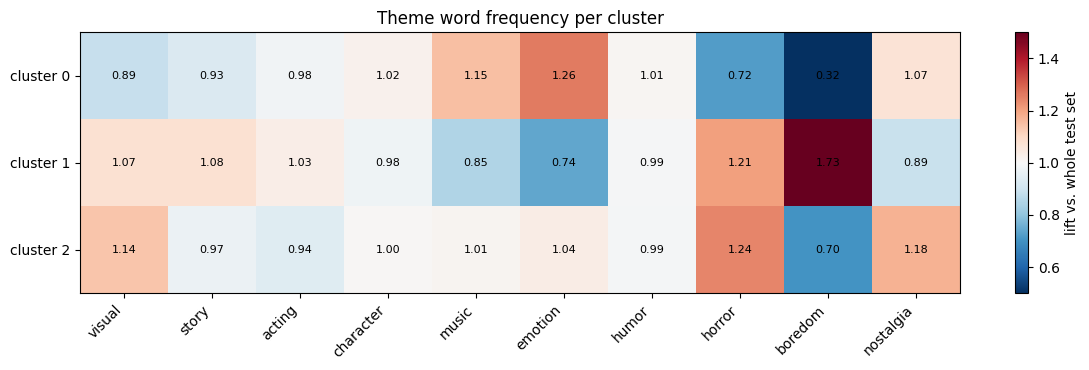

In [23]:
THEMES = {
    "visual":     ["cinematography", "visual", "visuals", "effects", "cgi", "shot", "shots", "camera", "scenery", "photography"],
    "story":      ["plot", "story", "storyline", "script", "writing", "ending", "twist", "narrative"],
    "acting":     ["acting", "actor", "actors", "actress", "performance", "performances", "cast", "role"],
    "character":  ["character", "characters", "development", "depth", "believable"],
    "music":      ["music", "soundtrack", "score", "song", "songs", "sound"],
    "emotion":    ["cry", "cried", "tears", "moving", "touching", "heart", "emotional", "sad"],
    "humor":      ["funny", "laugh", "laughed", "hilarious", "comedy", "jokes", "humor"],
    "horror":     ["horror", "scary", "gore", "blood", "zombie", "creepy", "slasher"],
    "boredom":    ["boring", "waste", "dull", "slow", "worst", "awful", "terrible"],
    "nostalgia":  ["childhood", "remember", "classic", "old", "kid", "kids", "years"],
}

words = test_df.text.str.lower().str.findall(r"[a-z']+").apply(set)
theme_hits = pd.DataFrame({t: words.apply(lambda w, ks=set(ks): bool(w & ks)) for t, ks in THEMES.items()})
theme_hits["cluster"] = test_df.cluster

# Rate of each theme inside a cluster divided by its rate over the whole test set (>1 = over-represented)
lift = theme_hits.groupby("cluster").mean() / theme_hits.drop(columns="cluster").mean()

plt.figure(figsize=(12, 0.6 * K_CHOSEN + 2))
plt.imshow(lift.values, cmap="RdBu_r", vmin=0.5, vmax=1.5, aspect="auto")
plt.colorbar(label="lift vs. whole test set")
plt.xticks(range(len(THEMES)), lift.columns, rotation=45, ha="right")
plt.yticks(range(K_CHOSEN), [f"cluster {c}" for c in lift.index])
for i in range(lift.shape[0]):
    for j in range(lift.shape[1]):
        plt.text(j, i, f"{lift.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Theme word frequency per cluster")
plt.tight_layout()
plt.show()

In [24]:
dist = kmeans.transform(X)
for c in range(K_CHOSEN):
    idx = np.where(kmeans.labels_ == c)[0]
    closest = idx[np.argsort(dist[idx, c])[:3]]
    show(test_df.iloc[closest], f"CLUSTER {c}: reviews closest to the centre", n_chars=300)

CLUSTER 0: reviews closest to the centre
[P(positive) = 0.9852 | true label: positive]
John Cassavette's decided as his first film, obviously as one shot on a shoestring in New York, to not even have a script with dialog, and delivers a 1959 feature equivalent of Larry David's Curb Your Enthusiasm- all the actors know what to do and say and even have the right look in their eyes when ...
----------------------------------------------------------------------------------------------------
[P(positive) = 0.9857 | true label: positive]
If you love Vampire lore and are a fan of Gothic horror, then you might want to check out Soul's Midnight. I did not know much about this movie before I watched it, and I wasn't expecting much, but I found the movie to be fun and entertaining.  Starring Armand Assante as the leader of the vampires S...
----------------------------------------------------------------------------------------------------
[P(positive) = 0.9846 | true label: positive]
When the Ro

### 6.4 Findings

**Choosing k.** The silhouette score falls steadily from k = 2 (0.822) to k = 10 (0.495), so the
cleanest split is simply positive versus negative. The elbow plot, however, has a sharp elbow at
k = 3: inertia drops from about 156k to 58k between k = 2 and k = 3 and only slowly after that.
k = 3 still has a high silhouette (0.793), so it was used for interpretation.

| Cluster | Size | % positive | Mean P(positive) | Mean length (words) | Distinctive words / themes | Proposed label |
|---|---|---|---|---|---|---|
| 0 | 10,891 | 96.1% | 0.983 | 215 | great, love, best, excellent, wonderful, beautiful, music, favorite; emotion x1.26, music x1.15, boredom x0.32 | **Enthusiastic / emotionally engaged** |
| 1 | 11,287 | 4.3% | 0.021 | 220 | bad, worst, awful, waste, boring, stupid, minutes, script, money; boredom x1.73, horror x1.21, emotion x0.74 | **Dismissive / bored** |
| 2 | 2,822 | 55.0% | 0.631 | 296 | man, wife, police, dead, doctor, car, "pretty", "of course"; horror x1.24, nostalgia x1.18, visual x1.14 | **Ambivalent, plot-describing reviews** |

(The "xN" values are the theme lifts from the heatmap: how often a cluster mentions a theme compared
with the whole test set.)

**What the clusters show.**

- **Clusters 0 and 1 are the two sentiment poles.** They hold 88% of the test set and are almost
  pure (96% and 96% one label). Their theme profiles make sense: positive reviewers talk about
  emotional impact and music, negative reviewers about boredom, wasted time and money, and bad
  scripts. Horror is over-represented among negative reviews, which fits the many low-budget horror
  films in IMDb.
- **Cluster 2 is the only structure beyond positive/negative.** It sits on the bridge between the two
  poles in both the PCA arc and the t-SNE plot. Its labels are split almost evenly (55% positive),
  and its mean predicted score of 0.63 shows the model is uncertain there. Its reviews are about 35%
  longer, and its distinctive words are not evaluative. They are plot-summary nouns (man, wife,
  police, doctor, car, character names such as Chaplin and Jack) plus hedges ("pretty", "of course").
  These reviewers mostly *retell the story* and give a lukewarm or mixed verdict, often about genre
  films and older classics (horror x1.24, nostalgia x1.18).
- **Aspect themes do not form their own clusters.** Visual, story, acting and character lifts all stay
  between about 0.9 and 1.15 in every cluster. No cluster corresponds to "visual" or "story"
  enjoyment. This is expected: the 64-d embedding was trained only on a binary sentiment objective,
  so it keeps mainly one axis (how positive) plus a confidence dimension, which is why PCA shows a
  one-dimensional arc. Recovering aspect-level themes would need embeddings that were not
  collapsed onto sentiment, such as the pre-trained BERT embeddings from section 3, or an
  aspect-aware training objective.

**How these insights could be used.**

- *Sentiment models:* cluster 2 is effectively a "mixed / uncertain" class. A three-way output
  (positive, negative, mixed), or routing low-confidence cluster-2 reviews to a human or a larger
  model, would handle the ambiguous reviews that a binary model has to guess on. The sarcasm and
  "so bad it's good" errors from 5.2 point the same way: these reviews need context the binary
  labels do not provide.
- *Aspect-based sentiment:* since the themes are present in the text (the heatmap lifts are real)
  but not in the embedding, an aspect-based model that scores acting, story, visuals and music
  separately would let a recommender match users to what they value, for example recommending
  films praised for cinematography to users whose own reviews emphasise visuals.
- *Recommendation systems:* separating "emotionally engaged" fans (cluster 0) from "dismissive"
  reviewers (cluster 1) and from "plot-describing, ambivalent" reviewers (cluster 2) is a useful
  reviewer-level signal. Enthusiastic reviews are better recommendation evidence than lukewarm plot
  summaries, even when both carry a positive label.

## 7. Conclusion

- **Pre-trained embeddings (section 3):** BERT's raw [CLS] and mean-pooled embeddings do not separate
  positive from negative reviews; the classes overlap in PCA and only loosely separate in t-SNE.
- **Fine-tuning (sections 4 and 5):** after 2 epochs, the fine-tuned `bert-base-uncased` reaches
  **92.15% accuracy, 0.910 precision, 0.935 recall and 0.923 F1** on the 25,000-review test set. The
  most confident predictions match human judgement. The confident mistakes come mostly from
  sarcasm, "so bad it's good" reviews, and labels that contradict the review text.
- **Clustering (section 6):** the fine-tuned 64-d embedding space is dominated by sentiment. K-means
  finds a positive pole, a negative pole and a third, smaller cluster of long, ambivalent,
  plot-describing reviews on which the model is uncertain. Aspect themes such as visuals, story or
  music do not form their own clusters, because binary fine-tuning collapses the embedding onto the
  sentiment axis.